In [401]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [402]:
df= pd.read_csv('WineQT.csv')

In [403]:
#EDA
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='str')

In [404]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [405]:
df.shape

(1143, 13)

In [406]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [407]:
df.duplicated().sum()

0

<Axes: xlabel='quality', ylabel='fixed acidity'>

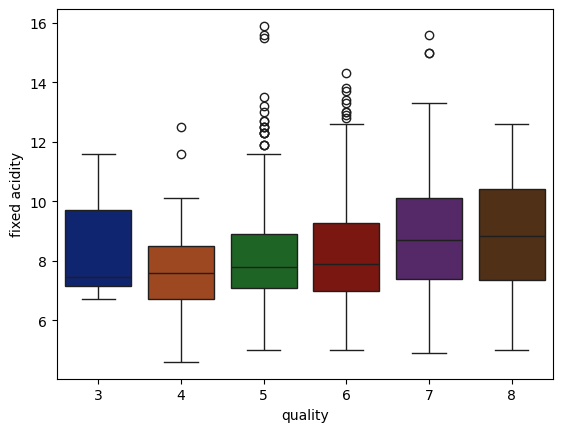

In [408]:
sns.boxplot(y=df['fixed acidity'],x=df['quality'],palette='dark')

<Axes: xlabel='quality', ylabel='residual sugar'>

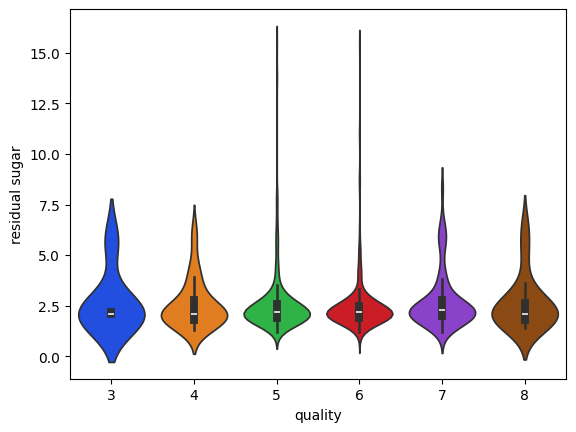

In [409]:
sns.violinplot(y=df['residual sugar'],x=df['quality'],palette='bright')

In [410]:
x = df.drop(columns=['Id','quality'])
y = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [411]:
#Preprocess
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [412]:
#model selection
from sklearn.model_selection import train_test_split

In [413]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42,stratify=y)

In [414]:
col=['fixed acidity','residual sugar','free sulfur dioxide','total sulfur dioxide','pH','alcohol']
X_train[col]=scaler.fit_transform(X_train[col])
X_test[col]=scaler.fit_transform(X_test[col])

In [415]:
#algorithm selection
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [416]:
models = ({
    'logisticregression':LogisticRegression(),
    'KNN':KNeighborsClassifier(),
    'Naive Bayes':GaussianNB(),
    'decisiontree' : DecisionTreeClassifier(random_state=42),
    'SVM(RBF)': SVC(kernel='rbf',random_state=42)

})

In [417]:
result=[]

In [418]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    #classificationreport=classification_report(y_pred,y_test)
    result.append({
        'Model' : name,
        'Accuracy':round(accuracy,2),
        'f1 score': round(f1,2)
       # 'Classification  Report': print(classificationreport)
          })

    

In [419]:
result

[{'Model': 'logisticregression', 'Accuracy': 0.86, 'f1 score': 0.33},
 {'Model': 'KNN', 'Accuracy': 0.83, 'f1 score': 0.29},
 {'Model': 'Naive Bayes', 'Accuracy': 0.82, 'f1 score': 0.44},
 {'Model': 'decisiontree', 'Accuracy': 0.85, 'f1 score': 0.47},
 {'Model': 'SVM(RBF)', 'Accuracy': 0.85, 'f1 score': 0.14}]

In [421]:
#we can use this method to print best method

# result.append({
#         print(f"\n{name}"),
#         print(confusion_matrix(y_test, y_pred)),
#         print(f"Accuracy {accuracy_score(y_test,y_pred)}"),
#         print(classification_report(y_test, y_pred))